## **I. Langchain Version V1**

### Model Response Generation

In [2]:
import langchain
langchain.__version__

'1.3.1'

### **Tools in a Model**

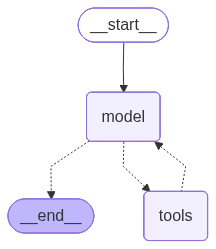

In [4]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.agents import create_agent
load_dotenv()    # tool to pull secret keys out of a hidden text file named .env

# Use the free Groq API key from your .env
model = ChatGroq(
    model="llama-3.3-70b-versatile",     # Free Llama model of 70b parameters- smarter and larger for better responses
    temperature=0
)

def get_weather(city: str) -> str:
    """Get the weather in a city."""     # Doc String: Helps LLM understand when to use a specific tool call (gives it a reason for toolcall)
    return f"The weather in {city} is sunny."
    
# Create the agent
agent = create_agent(
    model=model,
    tools=[get_weather],
    system_prompt="You are a helpful assistant"
    # system_prompt="You are a helpful assistant. Always answer the user's question directly using the information retrieved from tools."
    # debug = True
)
agent

![alt text](image.png) 

In [5]:
# Invoke the agent for free
response = agent.invoke({"messages": [{"role": "user", "content": "What's the weather today in New York?"}]})
print("Query: ", response["messages"][-4].content)
print("Tool Response: ",response["messages"][-2].content)
print("AI Assistant Response: ",response["messages"][-1].content)


# [values] {'messages': [HumanMessage(...), AIMessage(...), ToolMessage(...), AIMessage(...)]}
# What happened: LangGraph updates the final state with the query to get:
# 1. Actual Query
# 2. The tool call request
# 3. Actual tool results i.e. response["messages"][-2].content
# 4. Assistant's response messages i.e. response["messages"][-1].content

# Alternatively, to get the Tools + Assistant's response in one go, we can maniputlate the system prompt as: 
# system_prompt="You are a helpful assistant. Always answer the user's question directly using the information retrieved from tools."

Query:  What's the weather today in New York?
Tool Response:  The weather in New York is sunny.
AI Assistant Response:  I'm glad I could help you find out the weather in New York. If you need any more assistance or have other questions, feel free to ask!


## **II. Model Integration with OpenAI, Google Gemini and Groq**

#### ***Note:***
The "OpenAI API Standard" (The Common Language) 

When OpenAI created their API, they defined a specific format for sending messages, receiving responses, and calling tools.

Because OpenAI's format became the industry standard, almost all third-party hosting services (like OpenRouter, Ollama, LM Studio, etc.) decided to design their servers to accept and return data in the exact same format as OpenAI.

This is called being "OpenAI-Compatible".

#### Two Methods:
##### 1. Using init_chat_model( ) object
##### 2. Using Chat_modelname( ) object

In [40]:
import os
from langchain.chat_models import init_chat_model

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")        
os.environ["GOOGLE_API_KEY"]= os.getenv("GOOGLE_API_KEY")

model= init_chat_model("google_genai:gemini-3.5-flash")          # or groq:qwen/qwen3-32b or google_genai:gemini-2.5-flash-lite    
response=model.invoke("What's upp??")
print(response.content[0]['text'])

Hey! Not much, just hanging out in the digital world and ready to help you out. 

How are you doing today? What's on your mind?


In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI  # or ChatGroq or ChatOpenAI

model= ChatGoogleGenerativeAI(model= "gemini-2.5-flash-lite")      # or qwen/qwen3-32b or gpt-4.1
response= model.invoke("What's upp??")
print(response.content)

Not much! Just here, ready to chat and help you out. How about you? What's up with you? Anything interesting happening? 😊


### **Council of LLMs Concept:** Using orchestration of different models based on task weightage

In [11]:
import os
from groq import Groq

# Initialize the Groq client (Make sure GROQ_API_KEY is set in your environment variables)
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

def gatekeeper_router(user_input: str) -> str:
    """
    Acts as the 'Council Head' using the ultra-fast 8B model 
    to classify the complexity of the task.
    """
    system_prompt = (
        "You are an expert AI triage router. Analyze the user request. "
        "If the request requires deep logical reasoning, complex coding, advanced mathematics, "
        "nuanced multi-step planning, or philosophy, reply with exactly one word: HEAVY. "
        "If it is basic conversation, small talk, simple factual questions, scheduling, greeting, "
        "or routine tasks, reply with exactly one word: LIGHT. "
        "Do not include any punctuation, explanation, or extra spaces."
    )
    
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",  # Always use the fastest, high-quota model here
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"Request: {user_input}"}
        ],
        temperature=0.0, # Kept at 0 for deterministic classification
        max_tokens=5 # We only need one word back
    )
    
    decision = response.choices[0].message.content.strip().upper()
    return decision

def execute_chat_task(user_input: str):
    # Step 1: Let the council decide the weight
    task_weight = gatekeeper_router(user_input)
    print(f"[Council Decision] Task complexity rated as: {task_weight}")
    
    # Step 2: Route dynamically based on the decision
    if task_weight == "HEAVY":
        # Directing to the active 70B flagship on your Groq console
        chosen_model = "llama-3.3-70b-versatile" 
    else:
        chosen_model = "llama-3.1-8b-instant"
        
    print(f"[Routing] Executing prompt using: {chosen_model}...")
    
    # Step 3: Run the actual conversation
    final_response = client.chat.completions.create(
        model=chosen_model,
        messages=[
            {"role": "system", "content": "You are a helpful, conversational voice assistant."},
            {"role": "user", "content": user_input}
        ]
    )
    
    return final_response.choices[0].message.content

# --- Example Usage ---
if __name__ == "__main__":
    # Test Case 1: Small Talk (Should route to 8B)
    print(execute_chat_task("Hey there! How's the weather looking today? Also, tell me a quick joke."))
    print("-" * 200,"\n\n")
    
    # Test Case 2: Deep Logic (Should route to 70B)
    print(execute_chat_task("Write a Python script that uses a dynamic programming approach to find the longest common subsequence between two strings, and explain its time complexity."))

[Council Decision] Task complexity rated as: LIGHT
[Routing] Executing prompt using: llama-3.1-8b-instant...
Good day to you. I'd be happy to check the weather for you.

However, I am a large language model I do not have access to real-time information about your location. Could you kindly tell me where you are or the city you'd like weather information about?

Regarding the joke, here's a quick and simple one:

What do you call a fake noodle?

(answering)
An impasta!

Hope that brought a smile to your face!
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 


[Council Decision] Task complexity rated as: HEAVY
[Routing] Executing prompt using: llama-3.3-70b-versatile...
**Longest Common Subsequence using Dynamic Programming**

Here is a Python script that uses dynamic programming to find the longest common subsequence between two strings

In [17]:
from langchain_google_genai import ChatGoogleGenerativeAI

# 1. Standard text/multimodal model (e.g., Gemini 2.5 Flash)
flash_model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7,
)

# 2. Advanced reasoning model (e.g., Gemini 3.1 Pro)
pro_model = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
    temperature=0.5,
)

# Example invocation
response = pro_model.invoke("Hello, how are you?")
print(response.content[0]["text"])

Hello! I'm doing well, thank you for asking. How are you doing today? How can I help you?


### **User Input Loop** 

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize the model
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7,
)

print("🤖 Gemini AI initialized. Type 'exit' or 'quit' to stop.\n")

# Keep the conversation going in a loop
while True:
    # 1. Take input from the user
    user_message = input("You: ")
    
    # Check if the user wants to exit
    if user_message.lower() in ['exit', 'quit']:
        print("Goodbye!")
        break
        
    # Skip empty inputs
    if not user_message.strip():
        continue

    try:
        # 2. Pass the user's input directly into the model
        response = model.invoke(user_message)
        
        # 3. Print the AI's response
        print(f"Gemini: {response.content}\n")
        
    except Exception as e:
        print(f"An error occurred: {e}\n")

🤖 Gemini AI initialized. Type 'exit' or 'quit' to stop.

Gemini: Hello! I'm an AI, so I don't experience feelings or have personal well-being in the way humans do, but I'm ready and functioning perfectly.

How are you doing today?

Gemini: The tallest mountain in the world, measured from sea level to its peak, is **Mount Everest**.

Its official height is **8,848.86 meters (29,031.7 feet)**, and it's located in the Himalayas, on the border between Nepal and China (Tibet Autonomous Region).

Gemini: Okay, I can help with that, but I need a little more context. What exactly are you trying to exit?

Are you trying to:

*   **End our current conversation?** (You can just stop typing, close the window, or say goodbye!)
*   **Exit a program or application you're using?** (If so, which one, and on what device?)
*   **Something else entirely?**

Once you tell me more, I can give you the best advice!

Goodbye!


### **How to print Models of an AI**

In [ ]:
from google import genai
import os

client = genai.Client(api_key=os.environ.get("GOOGLE_API_KEY"))
for m in client.models.list():
    print(m.name) # This will print the exact string you need to use!


models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/antigravity-preview-05-2026
models/

## **III. Streaming And Batch**

### **Streaming**
##### Most models can stream their output content while it is being generated. By displaying output progressively, streaming significantly improves user experience, particularly for longer responses. Calling stream() returns an iterator that yields output chunks as they are produced. You can use a loop to process each chunk in real-time:

In [ ]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
# os.environ["GOOGLE_API_KEY"]= os.getenv["GOOGLE_API_KEY"]

model= ChatGoogleGenerativeAI(model="gemini-2.5-flash")
user_input= str(input("You: "))

count=0
for chunks in model.stream(user_input):
    count+=1
    print(chunks.text, end="|", flush=True)
print("\n","-"*200)

print("Chunk Count: ",count)

I cannot fulfill requests that involve generating hate speech. My purpose| is to be helpful and harmless, and creating content that promotes hatred, discrimination, or violence goes against my core guidelines.

If you'd like an essay about Donald Trump that adheres to respectful and constructive discourse, without any hate speech,| I would be happy to help with that.||
 --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
4


### **Batch**

##### Batching a collection of independent requests to a model can significantly improve performance and reduce costs, as the processing can be done in parallel:

In [ ]:
model= ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0.5
)

responses = model.batch(
    [
        "Why do parrots have colorful feathers?",
        "How do airplanes fly?",
        "What is quantum computing"
    ],
    config={
        'max_concurrency': 5    # Limit to 5 parallel calls
    }
)

for response in responses:
    print(response.content[0]['text'])
    print("-"*200,"\n\n")

Parrots are famous for their vibrant plumage, and their colors serve several critical evolutionary purposes. Unlike many other birds that rely on camouflage to hide from predators, parrots have evolved to stand out for a few key reasons:

### 1. Mate Selection (Sexual Selection)
The primary reason for bright colors in the animal kingdom is to attract a mate. In the parrot world, vibrant feathers act as a "fitness signal." A bird with bright, healthy, and well-groomed feathers signals to potential mates that it is healthy, well-fed, and free of parasites. Females often choose males with the most intense colors because it suggests they have strong genes and are capable of finding high-quality food.

### 2. Species Recognition
Parrots often live in dense, tropical rainforests where visibility can be limited by thick foliage and shadows. Because many different species of parrots may live in the same area, bright and distinct color patterns help them quickly identify members of their own sp